In [1]:
import time

import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

from firm3d.field.boozermagneticfield import (
    BoozerRadialInterpolant,
    InterpolatedBoozerField,
)
from firm3d.field.trajectory_helpers import TrappedPoincare
from firm3d.util.constants import (
    ALPHA_PARTICLE_CHARGE,
    ALPHA_PARTICLE_MASS,
    FUSION_ALPHA_PARTICLE_ENERGY,
)
from firm3d.util.functions import proc0_print, setup_logging
from firm3d.util.mpi import comm_size, comm_world, verbose

# Can comment out these inputs below if call_DESC==False
from desc.ResonanceOpt.TRObj_func import TrappedResonanceObj
import desc.io
from desc.backend import set_device
set_device("cpu")
import jax.numpy as jnp

ERROR:2025-10-21 08:08:08,157:jax._src.xla_bridge:487: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/global/homes/j/jlabbate/.conda/envs/TrappedResonance/lib/python3.13/site-packages/jax/_src/xla_bridge.py", line 485, in discover_pjrt_plugins
    plugin_module.initialize()
    ~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/global/homes/j/jlabbate/.conda/envs/TrappedResonance/lib/python3.13/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
    ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/global/homes/j/jlabbate/.conda/envs/TrappedResonance/lib/python3.13/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE


In [2]:
#######################
# COMMON USER INPUTS #
# firm3d setup
boozmn_filename = "../inputs/boozmn_equil_Helios_E0092_DESC_fixed.nc" # make sure this matches the DESC input
neta_poinc = 10  # Number of eta initial conditions for poincare
ns_poinc = 20  # Number of s initial conditions for poincare
Nmaps = 1200  # Number of Poincare return maps to compute
modBin = 6.55 # T
tmax = 1e-2

# DESC setup
eq = desc.io.load("../inputs/equil_Helios_E0092_DESC_fixed.h5") # make sure this matches the firm3d input
rhos_desc = (np.linspace(0.1,0.9,150))**(1/2) # rho = sqrt(s)
alphas_desc = np.linspace(0,2*np.pi,3)
KE_frac_desc = np.array([0.01])
N=0 # QA
#######################

In [3]:
# Additional setup

Ekin = FUSION_ALPHA_PARTICLE_ENERGY * KE_frac_desc[0]
charge = ALPHA_PARTICLE_CHARGE
mass = ALPHA_PARTICLE_MASS

resolution = 48  # Resolution for field interpolation
ns_interp = resolution  # number of radial grid points for interpolation
ntheta_interp = resolution  # number of poloidal grid points for interpolation
nzeta_interp = resolution  # number of toroidal grid points for interpolation
order = 3  # order for interpolation
tol = 1e-8  # Tolerance for ODE solver
s_mirror = 0.5  # flux surface for mirroring
theta_mirror = np.pi / 2  # poloidal angle for mirroring
zeta_mirror = 0
helicity_M = 1  # helicity of field strength contours
helicity_N = N # =0 for QA
degree = 3  # Degree for Lagrange interpolation


# Setup logging to redirect output to file
#setup_logging(f"stdout_trapped_map_{resolution}_{comm_size}.txt")

In [ ]:
# field initialization
time1 = time.time()

bri = BoozerRadialInterpolant(boozmn_filename, order, no_K=True, comm=comm_world)

field = InterpolatedBoozerField(
    bri,
    degree,
    ns_interp=ns_interp,
    ntheta_interp=ntheta_interp,
    nzeta_interp=nzeta_interp,
)

time2 = time.time()
proc0_print("BRI and IBF time: ", time2 - time1)

In [ ]:
# Trapped Map particle tracing
time1 = time.time()

poinc = TrappedPoincare(
    field,
    helicity_M,
    helicity_N,
    s_mirror,
    theta_mirror,
    zeta_mirror,
    mass,
    charge,
    Ekin,
    modBin=modBin,
    ns_poinc=ns_poinc,
    neta_poinc=neta_poinc,
    Nmaps=Nmaps,
    comm=comm_world,
    solver_options={"reltol": tol, "abstol": tol, "axis": 0},
    tmax=tmax,
)

time2 = time.time()
proc0_print("poincare time: ", time2 - time1)

In [ ]:
# Poincare plotting
fig, ax = plt.subplots()
ax = poinc.plot_poincare(ax=ax)

In [4]:
# Run DESC objective function
pitch_invs_desc = jnp.array([modBin])
out = TrappedResonanceObj(eq,rhos_desc,pitch_invs_desc,KE_frac_desc,alphas_desc,N)
obj_val = out['obj'][:,0,0] # Only look at rho, for one pitch, for one energy
s_obj = np.linspace(0.1,0.9,len(obj_val))

Precomputing transforms


In [ ]:
# Plotting the objective function over the Poincare plot
Y = s_obj
X = np.linspace(0,2*np.pi,5)
Z = np.transpose(np.tile(obj_val, (5, 1)))
cs = ax.contourf(X,Y,Z,cmap='Blues')
fig.colorbar(cs, ax=ax)

ax = poinc.plot_poincare(ax=ax)
ax.figure.savefig('poincare_objective_overlay.png')

In [ ]:
# Saving Poincare plot for testing
import pickle
fig,ax = plt.subplots()
ax = poinc.plot_poincare(ax=ax)
pickle.dump(fig, open("testing.pkl", "wb"))

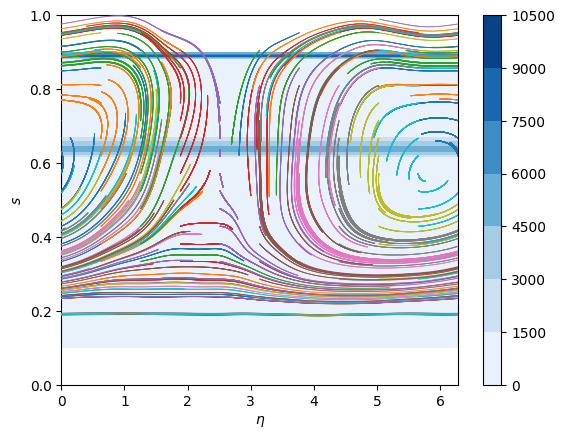

In [5]:
# Run after kernel restart to get Poincare plot back
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')  # Don't use interactive backend
import matplotlib.pyplot
import pickle
fig = pickle.load(open("testing.pkl", "rb"))

# now overplot DESC info
Y = s_obj
X = np.linspace(0,2*np.pi,5)
Z = np.transpose(np.tile(obj_val, (5, 1)))
ax = fig.axes[0]
cs = ax.contourf(X,Y,Z,cmap='Blues')
fig.colorbar(cs, ax=ax)
# fig.show()
# fig.savefig('testing.png')

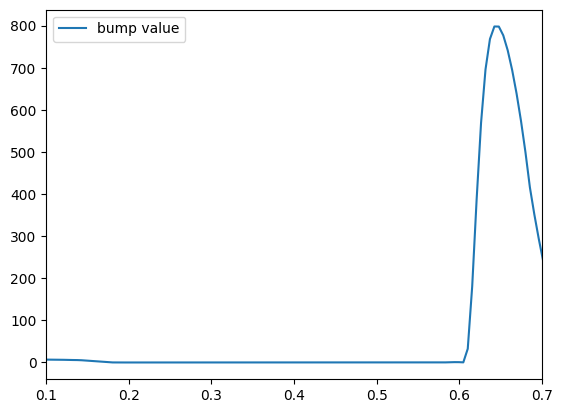

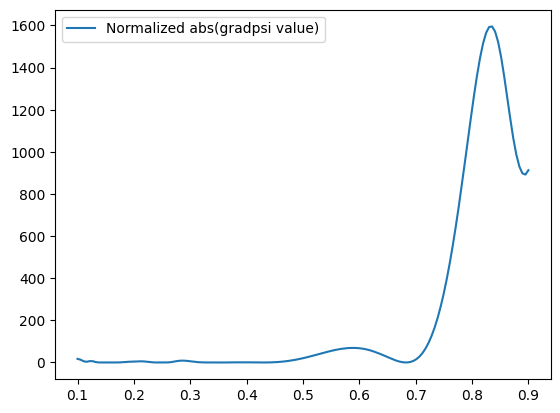

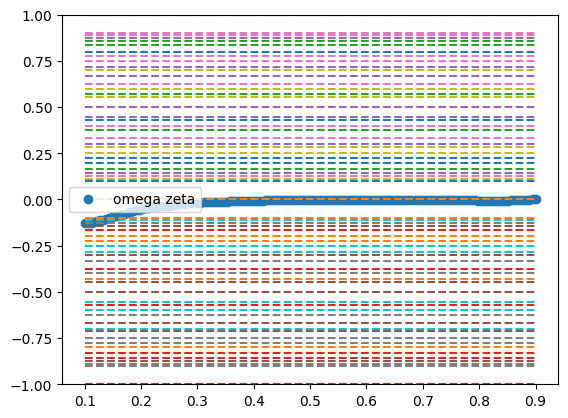

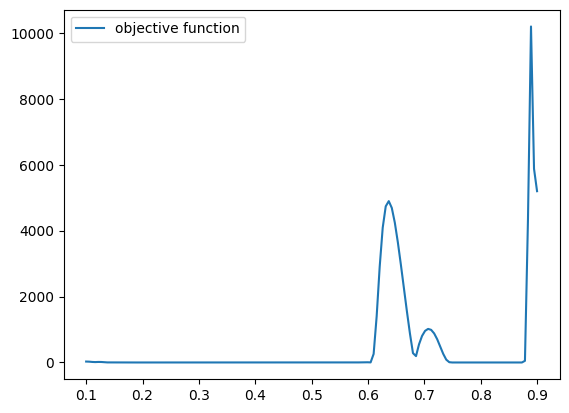

In [8]:
# Objective function testing
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')  # Don't use interactive backend
import matplotlib.pyplot

plt.figure(2)
plt.plot(rhos_desc**2,out['obj_bump'][:,0,0],label='bump value') # summed over all resonances
plt.xlim([0.1,0.7])
plt.legend()

plt.figure(3)
plt.plot(rhos_desc**2,out['psi_da'][:,0,0]**2,label='Normalized abs(gradpsi value)')
plt.legend()

ress = out['res'][0,0,0,:]
plt.figure(4)
plt.plot(rhos_desc**2,out['omega'][:,0,0,0],'o',label="omega zeta")
for res in ress:
    plt.plot(rhos_desc**2,np.ones(len(rhos_desc))*res,'--')
plt.ylim([-1,1])
plt.legend()

plt.figure(5)
plt.plot(rhos_desc**2,out['obj'][:,0,0],label="objective function")
plt.legend()

# import pickle
# fig,ax = plt.subplots()
# pickle.load(open("testing.pkl", "rb"))
# Y = s_obj
# X = np.linspace(0,2*np.pi,5)
# Z = np.transpose(np.tile(obj_val, (5, 1)))
# cs = ax.contourf(X,Y,Z,cmap='Blues')
# fig.colorbar(cs,ax=ax)


In [20]:
print(out['omega_d'][:,0,0,0])

[6.54415706e-02 6.73861814e-02 7.15690942e-02 9.54489770e-03
 9.05951382e-03 1.21870941e-02 1.42307092e-02 1.20339651e-02
 1.11887510e-02 1.25324920e-02 1.42591982e-02 1.47633391e-02
 1.42907419e-02 1.42177277e-02 1.42989939e-02 1.40730857e-02
 1.32414747e-02 1.19872772e-02 1.07502895e-02 9.71336758e-03
 8.80391776e-03 7.88291594e-03 6.92519656e-03 6.02977515e-03
 5.37921456e-03 5.09335206e-03 5.18713218e-03 5.54137501e-03
 5.96591885e-03 6.28263627e-03 6.36124106e-03 6.15045699e-03
 5.64265938e-03 4.94578524e-03 4.19822520e-03 3.51964932e-03
 2.97004469e-03 2.55444807e-03 2.26393962e-03 2.07105966e-03
 1.95855553e-03 1.90616168e-03 1.89371956e-03 1.90352547e-03
 1.92039912e-03 1.93212833e-03 1.92641450e-03 1.89760129e-03
 1.84544571e-03 1.77179432e-03 1.68140470e-03 1.57995145e-03
 1.47295556e-03 1.36596493e-03 1.26288314e-03 1.16575647e-03
 1.07595199e-03 9.94263907e-04 9.20972789e-04 8.55497370e-04
 7.97197348e-04 7.45332560e-04 6.99257256e-04 6.58470987e-04
 6.22496179e-04 5.906317

Text(0.5, 0, 'bruh')

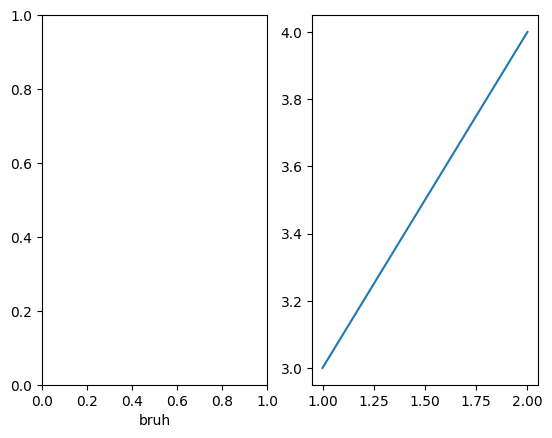

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(nrows=1, ncols=2)
ax[1].plot([1,2],[3,4])
ax[0].set_xlabel('bruh')

In [1]:
import numpy as np
x = np.linspace(0,1,5)
x.shape

(5,)